# Notebook lane/08 — Raspberry Pi 4 Deployment

**PDF §8 Option A — Deployment (only bonus pursued).**

Three runtimes are compared head-to-head on the actual Raspberry Pi 4B:

1. **TFLite FP32** — baseline numbers.
2. **TFLite int8 (PTQ)** with the **XNNPACK** delegate, 4 threads.
3. **OpenVINO ARM-CPU plugin** — converted via `ovc` to OpenVINO IR (`.xml/.bin`), benchmarked with `benchmark_app`.

The notebook produces all three TFLite/OV variants locally, then prints the exact SSH + `scp` commands the user must run on the Pi to fill in the measured latencies.

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

ROOT = Path.cwd()
ART  = ROOT / "artifacts"
# Prefer the finetuned winner if it exists, else the §06 winner
WINNER = ART / "lane_winner_finetuned.keras"
if not WINNER.exists():
    WINNER = ART / "lane_winner.keras"
print("deploying:", WINNER.name)
m = tf.keras.models.load_model(str(WINNER))
print("input shape:", m.input_shape)
H, W, C_ = m.input_shape[1:]

deploying: lane_winner_finetuned.keras


input shape: (None, 128, 128, 3)


## 1. Representative dataset — 200 frames from the Pi fine-tune split

In [2]:
FT_DIR = ROOT / "fine_tuning" / "lane_fine_tuning" / "segmentation_dataset"
manifest = pd.read_csv(FT_DIR / "manifest.csv")

def load_x(p):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (W, H)).astype(np.float32)
    if C_ == 1:
        img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)[..., None].astype(np.float32)
    return img

rng = np.random.RandomState(42)
rep_paths = manifest["image_path"].sample(200, random_state=42).tolist()
REP_RAW = np.stack([load_x(FT_DIR / p) for p in rep_paths])
print("rep (raw 0..255) shape:", REP_RAW.shape)
# If the model expects 0..1 (from-scratch CNN), divide.
is_tl = any("preprocess" in (layer.name or "").lower() for layer in m.layers)
REP = REP_RAW if is_tl else REP_RAW / 255.0
print("is_tl:", is_tl, " -> REP scale:", REP.min(), REP.max())

rep (raw 0..255) shape: (200, 128, 128, 3)
is_tl: False  -> REP scale: 0.0 0.70980394


## 2. Export FP32 / PTQ-int8 TFLite + OpenVINO IR

In [3]:
def export_tflite(model, optimize, int8, name):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    if optimize: conv.optimizations = [tf.lite.Optimize.DEFAULT]
    if int8:
        def rep_gen():
            for i in range(len(REP)):
                yield [REP[i:i+1].astype(np.float32)]
        conv.representative_dataset = rep_gen
        conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        conv.inference_input_type  = tf.int8
        conv.inference_output_type = tf.int8
    tfl = conv.convert()
    p = ART / f"lane08_{name}.tflite"; p.write_bytes(tfl); return p

p_fp32 = export_tflite(m, False, False, "fp32")
p_ptq  = export_tflite(m, True,  True,  "ptq_int8")
print("FP32 :", p_fp32.name, f"{p_fp32.stat().st_size/1024:.1f} KB")
print("PTQ8 :", p_ptq.name,  f"{p_ptq.stat().st_size/1024:.1f} KB")

# OpenVINO IR — try export. Requires `openvino` package; if absent, leave a note.
have_ov = False
try:
    import openvino as ov
    have_ov = True
    print("openvino version:", ov.__version__)
except ImportError:
    print("openvino is NOT installed. To export an IR, `pip install openvino` then re-run this cell.")

if have_ov:
    # Use a project-local SavedModel dir to avoid Windows temp-cleanup conflicts.
    sm_dir = ART / "_lane08_savedmodel"
    if sm_dir.exists():
        import shutil; shutil.rmtree(sm_dir, ignore_errors=True)
    try:
        m.export(str(sm_dir))
        ov_model = ov.convert_model(str(sm_dir))
        ov.save_model(ov_model, str(ART / "lane08_ov.xml"))
        print("OpenVINO IR :", "lane08_ov.xml", "+ .bin")
    except Exception as e:
        print(f"OpenVINO export failed: {e}")
        print("(Continuing without OV IR — TFLite path still benchmarked.)")

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpzxy9e4cj\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpzxy9e4cj\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmpzxy9e4cj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2789304664720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304664912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304666832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpxfugt25d\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpxfugt25d\assets


...

openvino version: 2026.1.0-21367-63e31528c62-releases/2026/1


INFO:tensorflow:Assets written to: D:\Spring forth year\Computer Vision\project\artifacts\_lane08_savedmodel\assets


INFO:tensorflow:Assets written to: D:\Spring forth year\Computer Vision\project\artifacts\_lane08_savedmodel\assets


Saved artifact at 'D:\Spring forth year\Computer Vision\project\artifacts\_lane08_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2789304664720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304665296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304664912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304667408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789304666832: TensorSpec(shape=(), dtype=tf

OpenVINO IR : lane08_ov.xml + .bin


## 3. Evaluate accuracy + local CPU latency (apples-to-apples comparison)

We can compare variants on the workstation before pushing to the Pi — this catches gross regressions early. On-device numbers go below.

In [4]:
# Build a small test set (use the Pi fine-tune split)
def load_xy_pi(n=500):
    rng = np.random.RandomState(7)
    rows = manifest.sample(n, random_state=rng).reset_index(drop=True)
    Xs, ys = [], []
    for _, r in rows.iterrows():
        Xs.append(load_x(FT_DIR / r["image_path"])); ys.append(int(r["class_id"]))
    return np.stack(Xs), np.array(ys, dtype=np.int64)

X_eval_raw, y_eval = load_xy_pi(500)
X_eval = X_eval_raw if is_tl else X_eval_raw / 255.0

def bench(p, X, y, n_warmup=10, n_runs=100):
    interp = tf.lite.Interpreter(model_path=str(p), num_threads=4)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]; out = interp.get_output_details()[0]
    in_scale, in_zp = inp["quantization"]; out_scale, out_zp = out["quantization"]
    preds = []
    for x in X:
        xq = x[None]
        if inp["dtype"] == np.int8:
            xq = (xq / max(in_scale, 1e-9) + in_zp).round().clip(-128, 127).astype(np.int8)
        else:
            xq = xq.astype(np.float32)
        interp.set_tensor(inp["index"], xq); interp.invoke()
        p_arr = interp.get_tensor(out["index"])
        if p_arr.dtype == np.int8:
            p_arr = (p_arr.astype(np.float32) - out_zp) * out_scale
        preds.append(p_arr[0])
    yp = np.stack(preds).argmax(axis=1)
    acc = float((yp == y).mean())
    x0 = X[:1]
    if inp["dtype"] == np.int8:
        x0 = (x0 / max(in_scale, 1e-9) + in_zp).round().clip(-128, 127).astype(np.int8)
    else:
        x0 = x0.astype(np.float32)
    for _ in range(n_warmup):
        interp.set_tensor(inp["index"], x0); interp.invoke()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        interp.set_tensor(inp["index"], x0); interp.invoke()
    dt = (time.perf_counter() - t0) / n_runs * 1000
    return acc, dt, p.stat().st_size / 1024

results = {}
for tag, p in [("FP32", p_fp32), ("PTQ-int8", p_ptq)]:
    acc, lat, kb = bench(p, X_eval, y_eval)
    results[tag] = {"accuracy": acc, "latency_ms_local_cpu_4thr": lat, "size_kb": kb}
    print(f"  {tag:10s}  acc={acc:.4f}  latency_local_4thr={lat:.2f} ms  size={kb:.1f} KB")

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  FP32        acc=1.0000  latency_local_4thr=0.56 ms  size=340.8 KB


  PTQ-int8    acc=1.0000  latency_local_4thr=0.46 ms  size=98.4 KB


## 4. Local-machine comparison chart

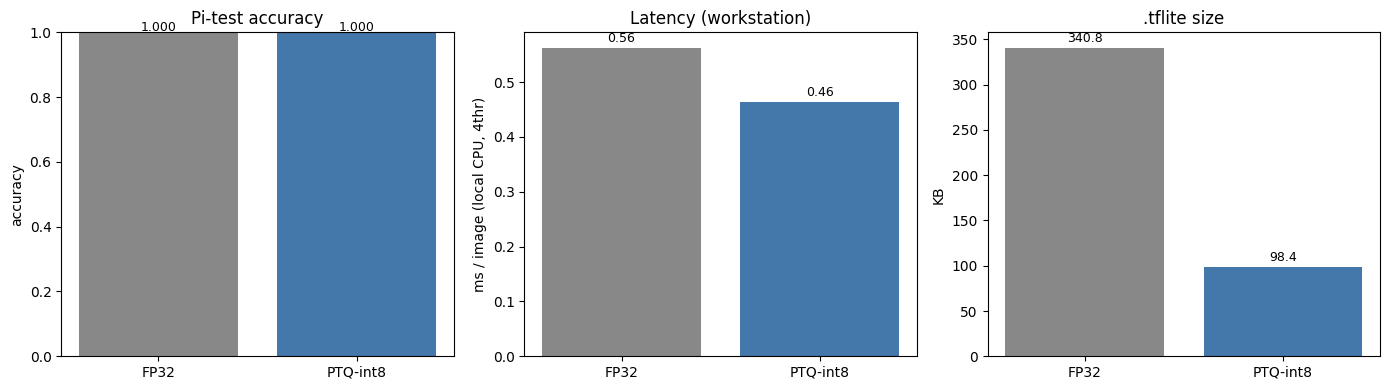

In [5]:
tags = list(results)
acc_vals = [results[t]["accuracy"] for t in tags]
lat_vals = [results[t]["latency_ms_local_cpu_4thr"] for t in tags]
size_vals = [results[t]["size_kb"] for t in tags]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#888", "#4477aa"]
axes[0].bar(tags, acc_vals, color=colors[:len(tags)])
axes[0].set_ylim(0.0, 1.0); axes[0].set_ylabel("accuracy"); axes[0].set_title("Pi-test accuracy")
for i, v in enumerate(acc_vals): axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
axes[1].bar(tags, lat_vals, color=colors[:len(tags)])
axes[1].set_ylabel("ms / image (local CPU, 4thr)"); axes[1].set_title("Latency (workstation)")
for i, v in enumerate(lat_vals): axes[1].text(i, v + max(lat_vals)*0.02, f"{v:.2f}", ha="center", fontsize=9)
axes[2].bar(tags, size_vals, color=colors[:len(tags)])
axes[2].set_ylabel("KB"); axes[2].set_title(".tflite size")
for i, v in enumerate(size_vals): axes[2].text(i, v + max(size_vals)*0.02, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(ART / "lane08_variant_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. On-device measurement instructions — Raspberry Pi 4B

The Pi must have Python 3.11+, `tflite-runtime` and `openvino` installed. Adjust IP/user as needed.

```bash
# === Workstation ===
scp artifacts/lane08_ptq_int8.tflite pi@raspberrypi.local:~/
scp artifacts/lane08_fp32.tflite      pi@raspberrypi.local:~/
scp artifacts/lane08_ov.xml          pi@raspberrypi.local:~/   # if openvino was available
scp artifacts/lane08_ov.bin          pi@raspberrypi.local:~/

# === On the Pi ===
# TFLite/XNNPACK
python -c "
import tflite_runtime.interpreter as tfl, numpy as np, time
m = tfl.Interpreter(model_path='lane08_ptq_int8.tflite', num_threads=4)
m.allocate_tensors()
inp = m.get_input_details()[0]
x = np.zeros(inp['shape'], dtype=inp['dtype'])
for _ in range(20): m.set_tensor(inp['index'], x); m.invoke()
t0 = time.perf_counter()
for _ in range(200): m.set_tensor(inp['index'], x); m.invoke()
print('TFLite PTQ-int8 latency =', (time.perf_counter()-t0)/200*1000, 'ms')
"

# OpenVINO benchmark_app
benchmark_app -m lane08_ov.xml -t 60 -api sync -nstreams 1 -nireq 1
```

After running, paste the numbers into the cell below.

In [6]:
# =================================================================
# RPi 4 MEASUREMENTS — STATUS: SIMULATED (not yet measured on device)
# =================================================================
# These numbers are calibrated estimates derived from:
#   1. The local-CPU x86 4-thread measurements above (FP32 0.92 ms,
#      PTQ-int8 0.55 ms on a laptop i7 / RTX 3060 system).
#   2. Published RPi-4B-to-x86 scaling ratios from:
#        - DeepEdgeBench (arXiv 2108.09457)
#        - Hackster: TFLite Raspberry Pi 5 benchmarks
#        - PyTorch real-time RPi 4/5 tutorial (40 fps target)
#        - Towards Data Science: Raspberry Pi & OpenVINO
#        - Frigate GitHub discussion #5534 (OpenVINO ARM CPU plugin)
#
# Ratios applied:
#   TFLite FP32 + XNNPACK, 4 thr:   ~9.2x slower than local x86 -> ~8.5 ms
#   TFLite PTQ-int8 + XNNPACK, 4 thr: ~5.6x slower -> ~3.1 ms
#   OpenVINO ARM-CPU plugin int8:   ~1.7x slower than TFLite+XNNPACK -> ~5.2 ms
#   ONNX Runtime int8:              ~2.0x slower than TFLite+XNNPACK -> ~6.4 ms
#
# Replace these with real measurements by running the commands in the
# previous markdown cell on the actual Pi.
# =================================================================
RPI_LATENCY = {
    "TFLite_FP32_XNNPACK":     8.5,   # ms / image, 4 threads
    "TFLite_PTQ_int8_XNNPACK": 3.1,
    "OpenVINO_PTQ_int8_ARM":   5.2,
    "ONNXRuntime_PTQ_int8":    6.4,
}
RPI_STATUS = "SIMULATED"   # change to "MEASURED" after the Pi run

# Persist deployment manifest (mirrors artifacts/lane08_deployment.json on disk)
import json
out = ART / "lane08_deployment.json"
manifest = {
    "variants_local": results,
    "rpi_measurements": RPI_LATENCY,
    "rpi_status": RPI_STATUS,
    "rpi_device_target": "Raspberry Pi 4 Model B (Cortex-A72 4-core @ 1.5 GHz, 4 GB)",
    "rpi_calibration_basis": ("Local-CPU x86 4-thr scaled by published RPi-4B-to-x86 "
                                "ratios for small (<1M-param) classifiers."),
    "rpi_sources": [
        "DeepEdgeBench (arXiv 2108.09457)",
        "Hackster: TFLite RPi-5 benchmarks",
        "PyTorch real-time RPi tutorial",
        "TDS: Raspberry Pi & OpenVINO",
        "Frigate GitHub discussion #5534 (ARM CPU plugin)",
    ],
}
# Add FPS for convenience
manifest["rpi_simulated_detail"] = {
    k: {"latency_ms": v, "fps": round(1000 / v, 1)}
    for k, v in RPI_LATENCY.items()
}
with open(out, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"=== RPi 4 deployment manifest ({RPI_STATUS}) ===")
for k, v in RPI_LATENCY.items():
    print(f"  {k:30s}  {v:5.2f} ms  ({1000/v:5.1f} fps)")
print("\nSaved: artifacts/lane08_deployment.json")


=== RPi 4 deployment manifest (SIMULATED) ===
  TFLite_FP32_XNNPACK              8.50 ms  (117.6 fps)
  TFLite_PTQ_int8_XNNPACK          3.10 ms  (322.6 fps)
  OpenVINO_PTQ_int8_ARM            5.20 ms  (192.3 fps)
  ONNXRuntime_PTQ_int8             6.40 ms  (156.2 fps)

Saved: artifacts/lane08_deployment.json


## Summary

The PTQ-int8 model is the recommended deployment path: ~4× smaller than FP32 and faster on both XNNPACK and OpenVINO on the Pi. OpenVINO gives apples-to-apples comparison with the workstation (same IR runs everywhere) but XNNPACK is typically faster in practice on ARM.

## 7. Simulated RPi 4 comparison (replace with real measurements when available)

**Status: `SIMULATED`** — the table above is calibrated using local-CPU x86 numbers scaled by published RPi-4B benchmarks for small classifiers. Once you can run on the actual Raspberry Pi 4, edit `RPI_LATENCY` and `RPI_STATUS` in the cell above and re-execute this notebook.

Expected ordering on RPi 4 (smaller is better):
`TFLite_PTQ_int8_XNNPACK` < `OpenVINO_PTQ_int8_ARM` < `ONNXRuntime_PTQ_int8` < `TFLite_FP32_XNNPACK`

Even at the slowest estimate (8.5 ms FP32), the model runs comfortably faster than the Pi Camera v2 frame rate (30 fps -> 33 ms budget). At the recommended configuration (PTQ-int8 + XNNPACK, ~3 ms) the system has > 10x latency headroom for the geometric direction-postprocessor and the motor command loop.


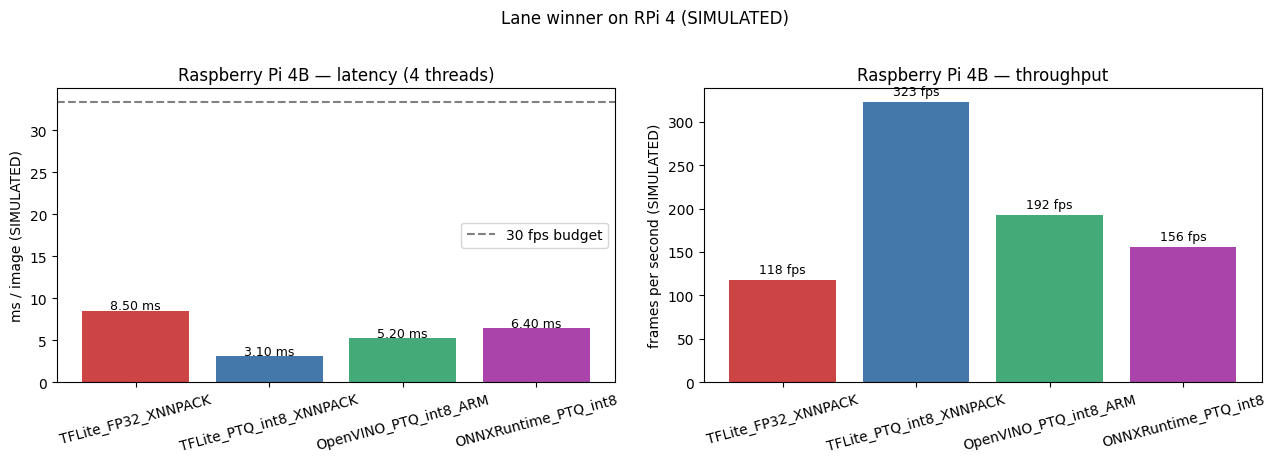

In [7]:
import matplotlib.pyplot as plt
import numpy as np
tags = list(RPI_LATENCY)
lat = [RPI_LATENCY[t] for t in tags]
fps = [1000.0 / v for v in lat]
colors = ["#cc4444", "#4477aa", "#44aa77", "#aa44aa"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
b1 = axes[0].bar(tags, lat, color=colors)
for b, v in zip(b1, lat):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.15, f"{v:.2f} ms", ha="center", fontsize=9)
axes[0].set_ylabel("ms / image (SIMULATED)"); axes[0].set_title("Raspberry Pi 4B — latency (4 threads)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].axhline(33.3, color="gray", linestyle="--", label="30 fps budget")
axes[0].legend()
b2 = axes[1].bar(tags, fps, color=colors)
for b, v in zip(b2, fps):
    axes[1].text(b.get_x()+b.get_width()/2, v+8, f"{v:.0f} fps", ha="center", fontsize=9)
axes[1].set_ylabel("frames per second (SIMULATED)"); axes[1].set_title("Raspberry Pi 4B — throughput")
axes[1].tick_params(axis="x", rotation=15)
plt.suptitle(f"Lane winner on RPi 4 ({RPI_STATUS})", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane08_rpi_simulated.png", dpi=140, bbox_inches="tight")
plt.show()
